<a href="https://colab.research.google.com/github/Dania-Yasir/flyrak-project/blob/main/work/notebooks/w05_final_capstone_model_%D8%A7%D9%84%D9%85%D9%88%D8%AF%D9%84_%D8%A7%D9%84%D9%86%D9%87%D8%A7%D8%A6%D9%8A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Capstone Model — Content Decline Ranking

**Selected model:** Random Forest — Full Signal

This is the single final capstone notebook. It contains:

- problem framing and temporal data boundary;
- feature engineering and leakage checks;
- Momentum baseline;
- Logistic Regression and Random Forest comparisons;
- balanced unseen-client validation;
- signal-above-Momentum ablation;
- macro-client evaluation;
- random-vs-grouped diagnostic;
- feature importance and out-of-fold error analysis;
- splitter sensitivity stress test;
- final model decision and limitations.

The main question is:

> **Can pre-outcome context improve ranking of future-decline pages beyond recent Momentum while still generalizing to unseen clients?**


<a href="https://colab.research.google.com/github/Dania-Yasir/flyrak-project/blob/main/work/notebooks/w05_model_logical_random_grouped_balanced_clients.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — Logical Model: Random vs Grouped Validation

## Can ML add signal above Momentum?

This notebook keeps the FlyRank methodology simple and explicit.

### Models
- Logistic Regression
- Random Forest

### Baseline
- Momentum-only heuristic

### Validation
- **Random row 5-fold**: kept in full as a diagnostic.
- **Client-grouped 5-fold**: used for the final claim because the question is generalization to unseen clients.

### Signal test
For each model family we compare:

1. **Momentum Features Only**
2. **Full Signal = Momentum + additional pre-outcome context**

The additional context includes:
- traffic level,
- 5-day trend shape,
- acceleration,
- decline consistency,
- CTR movement,
- search-position movement,
- activity movement,
- client-relative context.

If the Full Signal version does not beat its Momentum-only version, then the extra features did not earn their complexity.

### Important design choice

There is **no nested hyperparameter grid search** in this version. Model settings are fixed before validation, so the notebook is much faster and easier to defend. The same settings are used in Random and Grouped validation.

The final conclusion uses Grouped validation only. Random validation remains visible because the gap between Random and Grouped is itself an important FlyRank validation finding.


In [1]:
%pip install -q duckdb huggingface_hub pandas numpy scikit-learn matplotlib

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from getpass import getpass

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
PRIMARY_K = 100
MACRO_K = 10
DECLINE_THRESHOLD_PCT = -20.0
N_SPLITS = 5
SIMPLICITY_TIE_PP = 1.0

np.random.seed(RANDOM_STATE)

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)


pandas: 2.2.3
numpy: 2.1.3
scikit-learn: 1.6.1


## 1. Connect to the approved FlyRank warehouse

The token is read from Colab Secrets when available. It is never hardcoded or printed.

In [3]:
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = None

if not HF_TOKEN:
    HF_TOKEN = getpass("Enter your Hugging Face READ token: ")

if not HF_TOKEN:
    raise ValueError("A Hugging Face READ token is required.")

con = duckdb.connect()
safe_token = HF_TOKEN.replace("'", "''")
con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{safe_token}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT_MARCH = (
    f"read_parquet("
    f"'{REL}/fact_content_daily_performance/month=2026-03/*.parquet'"
    f")"
)

print("Connected successfully.")

Connected successfully.


## 2. Build a temporally clean modeling table

Prediction time is the end of **March 15, 2026**.

- Feature window: **March 1–15**
- Outcome window: **March 16–31**

The 15 feature days are also split into three 5-day blocks. Those blocks let us describe whether a decline is **accelerating, decelerating, or inconsistent**, instead of relying only on one early-vs-late momentum number.

The original 7-day / 8-day momentum definition is kept as the transparent anchor for comparability with the previous notebook.

In [4]:
query = f"""
SELECT
    client_hash_id AS client_id,
    content_hash_id AS content_id,

    -- Three equal pre-outcome blocks: Mar 1-5, 6-10, 11-15.
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-05'
             THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_w1,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-05'
             THEN COALESCE(gsc_clicks, 0) ELSE 0 END) AS clicks_w1,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-05'
             THEN COALESCE(gsc_sum_position, 0) ELSE 0 END) AS sum_position_w1,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-05'
                  AND COALESCE(gsc_impressions, 0) > 0
             THEN 1 ELSE 0 END) AS active_days_w1,

    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-06' AND DATE '2026-03-10'
             THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_w2,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-06' AND DATE '2026-03-10'
             THEN COALESCE(gsc_clicks, 0) ELSE 0 END) AS clicks_w2,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-06' AND DATE '2026-03-10'
             THEN COALESCE(gsc_sum_position, 0) ELSE 0 END) AS sum_position_w2,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-06' AND DATE '2026-03-10'
                  AND COALESCE(gsc_impressions, 0) > 0
             THEN 1 ELSE 0 END) AS active_days_w2,

    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-11' AND DATE '2026-03-15'
             THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_w3,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-11' AND DATE '2026-03-15'
             THEN COALESCE(gsc_clicks, 0) ELSE 0 END) AS clicks_w3,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-11' AND DATE '2026-03-15'
             THEN COALESCE(gsc_sum_position, 0) ELSE 0 END) AS sum_position_w3,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-11' AND DATE '2026-03-15'
                  AND COALESCE(gsc_impressions, 0) > 0
             THEN 1 ELSE 0 END) AS active_days_w3,

    -- Original momentum anchor: Mar 1-7 vs Mar 8-15.
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-07'
             THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_early7,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-08' AND DATE '2026-03-15'
             THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_late8,

    -- Coverage checks.
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-15'
                  AND COALESCE(gsc_data_available, FALSE)
             THEN 1 ELSE 0 END) AS gsc_days_features,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-16' AND DATE '2026-03-31'
                  AND COALESCE(gsc_data_available, FALSE)
             THEN 1 ELSE 0 END) AS gsc_days_future,

    -- Outcome only. Never enters the feature set.
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-16' AND DATE '2026-03-31'
             THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_future

FROM {FACT_MARCH}
WHERE report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-31'
GROUP BY client_hash_id, content_hash_id
"""

raw_df = con.execute(query).df()

print("Rows returned:", len(raw_df))
print("Clients returned:", raw_df["client_id"].nunique())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows returned: 331437
Clients returned: 55


## 3. Create the pre-outcome feature population first

This ordering matters.

Client-relative percentiles should describe what was knowable **at prediction time**. Therefore we first create the population with complete March 1–15 feature coverage, engineer every pre-outcome feature, and compute within-client ranks there.

Only **after that** do we restrict to pages with complete March 16–31 outcome coverage for evaluation.

In [5]:
feature_population = raw_df[raw_df["gsc_days_features"] == 15].copy()

feature_population["imp_first_half"] = (
    feature_population["imp_w1"]
    + feature_population["imp_w2"]
    + feature_population["imp_w3"]
)
feature_population["clicks_first_half"] = (
    feature_population["clicks_w1"]
    + feature_population["clicks_w2"]
    + feature_population["clicks_w3"]
)
feature_population["sum_position_first_half"] = (
    feature_population["sum_position_w1"]
    + feature_population["sum_position_w2"]
    + feature_population["sum_position_w3"]
)
feature_population["active_days_first_half"] = (
    feature_population["active_days_w1"]
    + feature_population["active_days_w2"]
    + feature_population["active_days_w3"]
)

# We need a non-zero pre-outcome reference level and a defined average position.
feature_population = feature_population[
    feature_population["imp_first_half"] > 0
].copy()

feature_population["avg_position_first_half"] = (
    feature_population["sum_position_first_half"]
    / feature_population["imp_first_half"]
)
feature_population = feature_population[
    feature_population["avg_position_first_half"].notna()
    & (feature_population["avg_position_first_half"] > 0)
].copy()

print("Feature-eligible pages before future filtering:", len(feature_population))
print("Feature-eligible clients:", feature_population["client_id"].nunique())

Feature-eligible pages before future filtering: 68288
Feature-eligible clients: 35


## 4. Engineer the signal above momentum

We separate features into three groups.

### A. Momentum anchor
The exact early-vs-late signal used by the simple heuristic.

### B. Context signal
Information that can explain **when a momentum decline is more likely to persist**:

- traffic and click level,
- 5-day trend shape,
- acceleration / deceleration,
- decline consistency across subwindows,
- CTR change,
- search-position change,
- activity change,
- client-relative scale.

### C. Full ML feature set
Momentum anchor + context signal.

For the **model+momentum blend**, the model is trained only on the context signal. That avoids simply feeding the same momentum score to the model and then counting it again in the blend.

In [6]:
def safe_pct_change(new_value, old_value):
    denom = np.maximum(np.asarray(old_value, dtype=float), 1.0)
    return ((np.asarray(new_value, dtype=float) - np.asarray(old_value, dtype=float)) / denom) * 100.0


# Stable levels.
feature_population["log_imp_first_half"] = np.log1p(feature_population["imp_first_half"])
feature_population["log_clicks_first_half"] = np.log1p(feature_population["clicks_first_half"])
feature_population["ctr_first_half"] = (
    feature_population["clicks_first_half"] / feature_population["imp_first_half"]
) * 100.0
feature_population["active_rate_first_half"] = feature_population["active_days_first_half"] / 15.0

# Original momentum anchor: daily-normalized Mar 1-7 vs Mar 8-15.
feature_population["avg_daily_imp_early7"] = feature_population["imp_early7"] / 7.0
feature_population["avg_daily_imp_late8"] = feature_population["imp_late8"] / 8.0
feature_population["imp_momentum_pct"] = safe_pct_change(
    feature_population["avg_daily_imp_late8"],
    feature_population["avg_daily_imp_early7"],
)
feature_population["imp_momentum_log"] = (
    np.log1p(feature_population["avg_daily_imp_late8"])
    - np.log1p(feature_population["avg_daily_imp_early7"])
)

# Equal 5-day blocks reveal shape, not just one start-vs-end number.
for w in (1, 2, 3):
    feature_population[f"avg_daily_imp_w{w}"] = feature_population[f"imp_w{w}"] / 5.0
    feature_population[f"avg_daily_clicks_w{w}"] = feature_population[f"clicks_w{w}"] / 5.0
    feature_population[f"ctr_w{w}"] = np.where(
        feature_population[f"imp_w{w}"] > 0,
        (feature_population[f"clicks_w{w}"] / feature_population[f"imp_w{w}"]) * 100.0,
        0.0,
    )
    feature_population[f"avg_position_w{w}"] = np.where(
        feature_population[f"imp_w{w}"] > 0,
        feature_population[f"sum_position_w{w}"] / feature_population[f"imp_w{w}"],
        np.nan,
    )
    feature_population[f"active_rate_w{w}"] = feature_population[f"active_days_w{w}"] / 5.0

feature_population["imp_step12_log"] = (
    np.log1p(feature_population["avg_daily_imp_w2"])
    - np.log1p(feature_population["avg_daily_imp_w1"])
)
feature_population["imp_step23_log"] = (
    np.log1p(feature_population["avg_daily_imp_w3"])
    - np.log1p(feature_population["avg_daily_imp_w2"])
)
feature_population["imp_acceleration"] = (
    feature_population["imp_step23_log"] - feature_population["imp_step12_log"]
)
feature_population["imp_declining_steps"] = (
    (feature_population["avg_daily_imp_w2"] < feature_population["avg_daily_imp_w1"]).astype(int)
    + (feature_population["avg_daily_imp_w3"] < feature_population["avg_daily_imp_w2"]).astype(int)
)
feature_population["imp_recent_vs_prior_log"] = (
    np.log1p(feature_population["avg_daily_imp_w3"])
    - np.log1p(
        (feature_population["avg_daily_imp_w1"] + feature_population["avg_daily_imp_w2"]) / 2.0
    )
)
feature_population["click_step23_log"] = (
    np.log1p(feature_population["avg_daily_clicks_w3"])
    - np.log1p(feature_population["avg_daily_clicks_w2"])
)
feature_population["ctr_change_5d_pp"] = feature_population["ctr_w3"] - feature_population["ctr_w1"]
feature_population["position_change_5d"] = (
    feature_population["avg_position_w3"] - feature_population["avg_position_w1"]
).fillna(0.0)
feature_population["has_position_shape"] = (
    feature_population["avg_position_w1"].notna()
    & feature_population["avg_position_w3"].notna()
).astype(int)
feature_population["active_rate_change_5d"] = (
    feature_population["active_rate_w3"] - feature_population["active_rate_w1"]
)

In [7]:
# Client-relative context is computed on the pre-outcome feature population.
client_groups = feature_population.groupby("client_id")

feature_population["log_imp_client_percentile"] = client_groups["log_imp_first_half"].rank(pct=True)
feature_population["ctr_client_percentile"] = client_groups["ctr_first_half"].rank(pct=True)
feature_population["position_client_percentile"] = client_groups["avg_position_first_half"].rank(pct=True)
feature_population["recent_vs_prior_client_percentile"] = client_groups["imp_recent_vs_prior_log"].rank(pct=True)

ANCHOR_FEATURES = [
    "imp_momentum_pct",
    "imp_momentum_log",
]

LEVEL_FEATURES = [
    "log_imp_first_half",
    "log_clicks_first_half",
    "ctr_first_half",
    "avg_position_first_half",
    "active_rate_first_half",
]

TREND_SHAPE_FEATURES = [
    "imp_step12_log",
    "imp_step23_log",
    "imp_acceleration",
    "imp_declining_steps",
    "imp_recent_vs_prior_log",
    "click_step23_log",
    "ctr_change_5d_pp",
    "position_change_5d",
    "active_rate_change_5d",
    "has_position_shape",
]

CLIENT_CONTEXT_FEATURES = [
    "log_imp_client_percentile",
    "ctr_client_percentile",
    "position_client_percentile",
    "recent_vs_prior_client_percentile",
]

CONTEXT_FEATURES = LEVEL_FEATURES + TREND_SHAPE_FEATURES + CLIENT_CONTEXT_FEATURES
FULL_FEATURES = ANCHOR_FEATURES + CONTEXT_FEATURES

print("Momentum anchor features:", len(ANCHOR_FEATURES))
print("Context-only features:", len(CONTEXT_FEATURES))
print("Full ML features:", len(FULL_FEATURES))

Momentum anchor features: 2
Context-only features: 19
Full ML features: 21


## 5. Create the outcome-evaluable cohort

The future window is used **only now** to decide which rows can be evaluated and to define the outcome label.

`is_declining_proxy = 1` means average daily impressions in March 16–31 are more than 20% below the March 1–15 average.

This is a decision-support proxy. It is not a causal refresh label and not a claim about Google's algorithm.

In [8]:
model_df = feature_population[
    feature_population["gsc_days_future"] == 16
].copy().reset_index(drop=True)

model_df["avg_daily_imp_first_half"] = model_df["imp_first_half"] / 15.0
model_df["avg_daily_imp_future"] = model_df["imp_future"] / 16.0
model_df["impression_change_pct"] = (
    (model_df["avg_daily_imp_future"] - model_df["avg_daily_imp_first_half"])
    / model_df["avg_daily_imp_first_half"]
) * 100.0
model_df["is_declining_proxy"] = (
    model_df["impression_change_pct"] < DECLINE_THRESHOLD_PCT
).astype(int)

target_col = "is_declining_proxy"

print("Modeling pages:", len(model_df))
print("Modeling clients:", model_df["client_id"].nunique())
print("Decline rate:", f"{model_df[target_col].mean():.1%}")
print("Missing feature values:", int(model_df[FULL_FEATURES].isna().sum().sum()))

Modeling pages: 61795
Modeling clients: 34
Decline rate: 32.4%
Missing feature values: 0


## 6. Coverage and selection audit

We report three populations separately:

1. all March rows returned,
2. pages with complete pre-outcome feature coverage,
3. pages that also have a complete future window and can therefore be evaluated.

This prevents the final result from being presented as if it covered the entire warehouse.

In [9]:
coverage_summary = pd.DataFrame([
    {
        "stage": "March rows returned",
        "rows": len(raw_df),
        "clients": raw_df["client_id"].nunique(),
    },
    {
        "stage": "Feature-eligible before future filtering",
        "rows": len(feature_population),
        "clients": feature_population["client_id"].nunique(),
    },
    {
        "stage": "Outcome-evaluable modeling cohort",
        "rows": len(model_df),
        "clients": model_df["client_id"].nunique(),
    },
])
coverage_summary["row_retention_vs_query"] = coverage_summary["rows"] / len(raw_df)
coverage_summary["client_retention_vs_query"] = coverage_summary["clients"] / raw_df["client_id"].nunique()

display(coverage_summary.style.format({
    "row_retention_vs_query": "{:.1%}",
    "client_retention_vs_query": "{:.1%}",
}))

client_sizes = model_df.groupby("client_id").size()
print("Client page-count distribution:")
display(client_sizes.describe().to_frame(name="pages").T)

,stage,rows,clients,row_retention_vs_query,client_retention_vs_query
0,March rows returned,331437,55,100.0%,100.0%
1,Feature-eligible before future filtering,68288,35,20.6%,63.6%
2,Outcome-evaluable modeling cohort,61795,34,18.6%,61.8%


Client page-count distribution:


,count,mean,std,min,25%,50%,75%,max
pages,34.0,1817.5,3886.560646,1.0,9.0,295.0,1114.0,16648.0


## 7. Leakage and information-boundary audit

The label, future impressions, IDs, and future-derived percentage change must never appear in the model feature lists.

Client IDs are used only for grouping, splitting, and within-client context. They are not model inputs.

In [10]:
forbidden_exact = {
    target_col,
    "imp_future",
    "avg_daily_imp_future",
    "impression_change_pct",
    "client_id",
    "content_id",
}

all_features = set(FULL_FEATURES)
forbidden_overlap = sorted(all_features.intersection(forbidden_exact))
future_named_features = sorted([
    c for c in FULL_FEATURES
    if "future" in c.lower() or "outcome" in c.lower() or "target" in c.lower()
])

print("Forbidden exact overlap:", forbidden_overlap)
print("Suspicious future-named features:", future_named_features)

assert not forbidden_overlap
assert not future_named_features
assert model_df[FULL_FEATURES].isna().sum().sum() == 0

print("Leakage guard passed: model features stop at March 15 and contain no IDs or outcome fields.")

Forbidden exact overlap: []
Suspicious future-named features: []
Leakage guard passed: model features stop at March 15 and contain no IDs or outcome fields.


## 8. Ranking metrics

### Primary
**Pooled Precision@100** inside each held-out outer fold. This matches the operational question: among the first 100 pages reviewed, how many truly decline in the future window?

### Client robustness
**Macro-client Precision@10**. We compute P@10 separately for every eligible held-out client with at least 10 pages, then average **once across clients after all outer folds finish**.

This fixes the old fold-of-fold macro averaging problem and avoids calling an entire small client's base rate “Precision@100”.

In [11]:
def precision_at_k(y_true, scores, k=100, random_state=RANDOM_STATE):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores, dtype=float)
    k = min(k, len(y_true))
    if k == 0:
        return np.nan

    rng = np.random.default_rng(random_state)
    tie_breaker = rng.random(len(scores))
    order = np.lexsort((tie_breaker, -scores))
    return float(y_true[order[:k]].mean())


def safe_average_precision(y_true, scores):
    y_true = np.asarray(y_true)
    if y_true.sum() == 0:
        return np.nan
    return float(average_precision_score(y_true, scores))


def safe_roc_auc(y_true, scores):
    y_true = np.asarray(y_true)
    if np.unique(y_true).size < 2:
        return np.nan
    return float(roc_auc_score(y_true, scores))


def evaluate_ranking(name, y_true, scores, k=PRIMARY_K):
    y_true = np.asarray(y_true)
    return {
        "model": name,
        "base_rate": float(y_true.mean()),
        "precision_at_10": precision_at_k(y_true, scores, 10),
        "precision_at_100": precision_at_k(y_true, scores, k),
        "average_precision": safe_average_precision(y_true, scores),
        "roc_auc": safe_roc_auc(y_true, scores),
    }


def momentum_only_scores(frame):
    # More negative early-vs-late momentum -> higher decline-risk score.
    return -frame["imp_momentum_pct"].to_numpy(dtype=float)


def percentile_rank(scores):
    return pd.Series(np.asarray(scores, dtype=float)).rank(method="average", pct=True).to_numpy()


def rank_blend_scores(model_scores, momentum_scores, model_weight):
    """Blend percentile ranks so different score scales are comparable."""
    model_rank = percentile_rank(model_scores)
    momentum_rank = percentile_rank(momentum_scores)
    return model_weight * model_rank + (1.0 - model_weight) * momentum_rank


def client_precision_rows(frame, scores, model_name, k=MACRO_K):
    tmp = frame[["client_id", target_col]].copy()
    tmp["_score"] = np.asarray(scores, dtype=float)
    rows = []

    for client_id, group in tmp.groupby("client_id", sort=False):
        if len(group) < k:
            continue
        p_at_k = precision_at_k(
            group[target_col].to_numpy(),
            group["_score"].to_numpy(),
            k=k,
            random_state=RANDOM_STATE,
        )
        base_rate = float(group[target_col].mean())
        rows.append({
            "client_id": client_id,
            "model": model_name,
            "client_pages": len(group),
            "client_base_rate": base_rate,
            "client_p_at_k": p_at_k,
            "client_lift_pp": p_at_k - base_rate,
        })

    return rows

## 9. Random and grouped split design

Both split styles are kept because they answer different questions.

### Random row split — diagnostic

`StratifiedKFold` preserves the decline-rate balance, but pages from the same client can appear in both training and validation.

This answers:

> How well does the model rank unseen **pages** when the client distribution is already familiar?

### Balanced client-grouped split — primary

A standard `StratifiedGroupKFold` keeps clients disjoint, but it does **not** guarantee a fair number of clients per fold. With highly unequal client sizes, it can create folds such as `11 / 1 / 10 / 1 / 11`.

That is not ideal for this capstone because a one-client test fold is too dependent on one client's behavior.

The grouped splitter below therefore uses a stricter rule:

1. every client appears in exactly one test fold;
2. client counts differ by at most one;
3. among assignments satisfying rule 2, choose the one that best balances:
   - total rows,
   - total positive/declining rows,
   - decline base rate.

For 34 clients and 5 folds, the client-count target is therefore:

> **7 / 7 / 7 / 7 / 6**

No model score is used to construct the folds. The target is used only for stratification/balance, never as a model feature.

### Why this is more defensible here

The project claim is about **generalization across clients**. A fold containing one client should not have the same influence on the conclusion as a fold containing eleven clients merely because that one client has many pages.

The Random split remains unchanged and is still reported in full.


In [12]:
def make_balanced_client_splits(
    frame,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
    n_restarts=500,
):
    """
    Client-disjoint K-fold splitter with an explicit client-count constraint.

    Guarantees:
    - each client appears in exactly one test fold;
    - fold client counts differ by at most one.

    Optimization target:
    - balance total rows;
    - balance positive rows;
    - balance decline base rate.

    Model performance is NEVER used when choosing the assignment.
    """
    stats = (
        frame.groupby("client_id")[target_col]
        .agg(rows="size", positives="sum")
        .reset_index()
    )
    stats["base_rate"] = (
        stats["positives"] / stats["rows"]
    )

    n_clients = len(stats)
    n_splits = min(int(n_splits), int(n_clients))

    if n_splits < 2:
        raise ValueError("At least two clients are required.")

    # Exact fold capacities.
    # Example: 34 clients, 5 folds -> [7, 7, 7, 7, 6].
    base = n_clients // n_splits
    remainder = n_clients % n_splits

    default_capacities = np.array(
        [
            base + (1 if i < remainder else 0)
            for i in range(n_splits)
        ],
        dtype=int,
    )

    total_rows = float(stats["rows"].sum())
    total_pos = float(stats["positives"].sum())
    global_rate = total_pos / total_rows

    target_rows = total_rows / n_splits
    target_pos = total_pos / n_splits

    rng_master = np.random.default_rng(random_state)
    best = None

    def final_cost(fold_rows, fold_pos):
        fold_rows = np.asarray(fold_rows, dtype=float)
        fold_pos = np.asarray(fold_pos, dtype=float)

        fold_rates = np.divide(
            fold_pos,
            fold_rows,
            out=np.zeros_like(fold_pos),
            where=fold_rows > 0,
        )

        row_imbalance = np.mean(
            ((fold_rows - target_rows) / max(target_rows, 1.0)) ** 2
        )
        pos_imbalance = np.mean(
            ((fold_pos - target_pos) / max(target_pos, 1.0)) ** 2
        )
        rate_imbalance = np.mean(
            (fold_rates - global_rate) ** 2
        )

        # Rows and positives matter most; rate balance is an additional guard.
        return (
            1.0 * row_imbalance
            + 1.25 * pos_imbalance
            + 3.0 * rate_imbalance
        )

    for restart in range(int(n_restarts)):
        rng = np.random.default_rng(
            int(rng_master.integers(0, 2**31 - 1))
        )

        # Randomly decide which folds receive the extra client(s),
        # so no fold number gets privileged.
        capacities = np.full(
            n_splits,
            base,
            dtype=int,
        )
        extra_order = rng.permutation(n_splits)
        capacities[extra_order[:remainder]] += 1

        work = stats.copy()

        # Place difficult-to-balance clients early:
        # large clients + clients with unusual base rate.
        work["_priority"] = (
            np.log1p(work["rows"])
            + 3.0 * np.abs(
                work["base_rate"] - global_rate
            )
            + rng.normal(
                0.0,
                0.05,
                size=len(work),
            )
        )
        work = (
            work.sort_values(
                "_priority",
                ascending=False,
            )
            .reset_index(drop=True)
        )

        fold_clients = [
            [] for _ in range(n_splits)
        ]
        fold_rows = np.zeros(
            n_splits,
            dtype=float,
        )
        fold_pos = np.zeros(
            n_splits,
            dtype=float,
        )

        for row in work.itertuples(index=False):
            eligible = [
                fold
                for fold in range(n_splits)
                if len(fold_clients[fold]) < capacities[fold]
            ]

            candidate_choices = []

            for fold in eligible:
                test_rows = fold_rows.copy()
                test_pos = fold_pos.copy()

                test_rows[fold] += float(row.rows)
                test_pos[fold] += float(row.positives)

                # Partial-state cost. Empty folds are intentionally penalized
                # through the row/positive imbalance terms.
                cost = final_cost(
                    test_rows,
                    test_pos,
                )

                candidate_choices.append(
                    (
                        cost,
                        rng.random(),
                        fold,
                    )
                )

            _, _, chosen_fold = min(
                candidate_choices
            )

            fold_clients[chosen_fold].append(
                row.client_id
            )
            fold_rows[chosen_fold] += float(
                row.rows
            )
            fold_pos[chosen_fold] += float(
                row.positives
            )

        score = final_cost(
            fold_rows,
            fold_pos,
        )

        if (
            best is None
            or score < best["score"]
        ):
            best = {
                "score": score,
                "fold_clients": [
                    list(x)
                    for x in fold_clients
                ],
                "fold_rows": fold_rows.copy(),
                "fold_pos": fold_pos.copy(),
            }

    splits = []

    for clients_in_fold in best["fold_clients"]:
        test_mask = frame["client_id"].isin(
            set(clients_in_fold)
        ).to_numpy()

        test_idx = np.flatnonzero(
            test_mask
        )
        train_idx = np.flatnonzero(
            ~test_mask
        )

        splits.append(
            (train_idx, test_idx)
        )

    # Verification.
    client_counts = [
        frame.iloc[test_idx]["client_id"].nunique()
        for _, test_idx in splits
    ]

    assert max(client_counts) - min(client_counts) <= 1

    all_test_clients = []
    for _, test_idx in splits:
        all_test_clients.extend(
            frame.iloc[test_idx][
                "client_id"
            ].drop_duplicates().tolist()
        )

    assert (
        len(all_test_clients)
        == len(set(all_test_clients))
        == frame["client_id"].nunique()
    )

    return splits, "BalancedClientKFold"


grouped_splits, grouped_strategy = (
    make_balanced_client_splits(
        model_df,
        n_splits=N_SPLITS,
        random_state=RANDOM_STATE,
        n_restarts=500,
    )
)

# Random row split is deliberately unchanged.
random_splitter = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
random_splits = list(
    random_splitter.split(
        model_df[FULL_FEATURES],
        model_df[target_col],
    )
)

fold_audit_rows = []

for fold, (_, test_idx) in enumerate(
    grouped_splits,
    start=1,
):
    fold_frame = model_df.iloc[test_idx]

    fold_audit_rows.append({
        "fold": fold,
        "clients": fold_frame["client_id"].nunique(),
        "rows": len(fold_frame),
        "positives": int(
            fold_frame[target_col].sum()
        ),
        "base_rate": float(
            fold_frame[target_col].mean()
        ),
        "momentum_p100": precision_at_k(
            fold_frame[target_col],
            momentum_only_scores(
                fold_frame
            ),
            PRIMARY_K,
        ),
    })

fold_audit = pd.DataFrame(
    fold_audit_rows
)

print(
    "Primary grouped strategy:",
    grouped_strategy,
)
print(
    "Expected client counts:",
    sorted(
        fold_audit["clients"].tolist(),
        reverse=True,
    ),
)

display(
    fold_audit.style.format({
        "base_rate": "{:.1%}",
        "momentum_p100": "{:.1%}",
    })
)

print(
    "Client-count range:",
    f"{fold_audit['clients'].min()}–"
    f"{fold_audit['clients'].max()}",
)
print(
    "Row-count range:",
    f"{fold_audit['rows'].min():,}–"
    f"{fold_audit['rows'].max():,}",
)
print(
    "Base-rate range:",
    f"{fold_audit['base_rate'].min():.1%}–"
    f"{fold_audit['base_rate'].max():.1%}",
)

assert (
    fold_audit["clients"].max()
    - fold_audit["clients"].min()
    <= 1
)

print(
    "Client-balance check passed: "
    "folds differ by at most one client."
)


Primary grouped strategy: BalancedClientKFold
Expected client counts: [7, 7, 7, 7, 6]


,fold,clients,rows,positives,base_rate,momentum_p100
0,1,7,10806,2633,24.4%,51.0%
1,2,7,11014,2714,24.6%,73.0%
2,3,7,10493,4377,41.7%,65.0%
3,4,6,16660,5545,33.3%,87.0%
4,5,7,12822,4754,37.1%,83.0%


Client-count range: 6–7
Row-count range: 10,493–16,660
Base-rate range: 24.4%–41.7%
Client-balance check passed: folds differ by at most one client.


## 10. Fixed model settings

To keep the experiment reproducible and fast, the settings below are fixed **before** validation.

They are deliberately conservative and close to the FlyRank reference setup.

### Logistic Regression
- standardized features,
- balanced class weights,
- moderate regularization.

### Random Forest
- 200 trees,
- depth 10,
- minimum 25 samples per leaf,
- balanced subsample class weights.

The same settings are used in Random and Grouped validation.


In [13]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=0.3,
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=25,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

MODEL_SPECS = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
}

FEATURE_SETS = {
    "Momentum Features Only": ANCHOR_FEATURES,
    "Full Signal": FULL_FEATURES,
}

print("Fixed Logistic Regression and Random Forest are ready.")


Fixed Logistic Regression and Random Forest are ready.


## 11. Primary evaluation — client-grouped 5-fold

This is the main capstone evaluation.

For every grouped fold:

1. hold out complete clients,
2. train on the remaining clients,
3. score the unseen clients once,
4. compare Momentum, Momentum-only models, and Full-Signal models on the same held-out rows.

No hyperparameter search is performed inside the folds.


In [14]:
grouped_rows = []
client_metric_rows = []
oof_frames = []
rf_importance_rows = []

APPROACHES = [
    "Momentum-only Baseline",
    "Logistic — Momentum Features Only",
    "Logistic Regression — Full Signal",
    "Random Forest — Momentum Features Only",
    "Random Forest — Full Signal",
]

for fold, (train_idx, test_idx) in enumerate(grouped_splits, start=1):
    train_part = model_df.iloc[train_idx].copy()
    test_part = model_df.iloc[test_idx].copy()

    assert set(train_part["client_id"]).isdisjoint(
        set(test_part["client_id"])
    )

    momentum_scores = momentum_only_scores(test_part)

    score_map = {
        "Momentum-only Baseline": momentum_scores,
    }

    fitted_rf_full = None

    for model_family, estimator in MODEL_SPECS.items():
        for feature_label, feature_cols in FEATURE_SETS.items():
            model = clone(estimator)
            model.fit(
                train_part[feature_cols],
                train_part[target_col],
            )
            scores = model.predict_proba(
                test_part[feature_cols]
            )[:, 1]

            if model_family == "Logistic Regression":
                approach_name = (
                    "Logistic — Momentum Features Only"
                    if feature_label == "Momentum Features Only"
                    else "Logistic Regression — Full Signal"
                )
            else:
                approach_name = (
                    "Random Forest — Momentum Features Only"
                    if feature_label == "Momentum Features Only"
                    else "Random Forest — Full Signal"
                )

            score_map[approach_name] = scores

            if (
                model_family == "Random Forest"
                and feature_label == "Full Signal"
            ):
                fitted_rf_full = model

    for name, scores in score_map.items():
        metrics = evaluate_ranking(
            name,
            test_part[target_col],
            scores,
        )

        grouped_rows.append({
            "fold": fold,
            "model": name,
            "test_clients": test_part["client_id"].nunique(),
            "test_rows": len(test_part),
            **{
                key: value
                for key, value in metrics.items()
                if key != "model"
            },
        })

        client_metric_rows.extend(
            client_precision_rows(
                test_part,
                scores,
                name,
                k=MACRO_K,
            )
        )

    # Safe out-of-fold diagnostics.
    fold_oof = test_part[[
        target_col,
        "log_imp_first_half",
        "imp_momentum_pct",
        "imp_acceleration",
        "imp_declining_steps",
        "ctr_change_5d_pp",
        "position_change_5d",
        "active_rate_change_5d",
    ]].copy()
    fold_oof["fold"] = fold

    for name, scores in score_map.items():
        fold_oof[f"score__{name}"] = scores

    oof_frames.append(fold_oof)

    # Fast RF importance: average built-in importances across unseen-client folds.
    for feature, importance in zip(
        FULL_FEATURES,
        fitted_rf_full.feature_importances_,
    ):
        rf_importance_rows.append({
            "fold": fold,
            "feature": feature,
            "importance": float(importance),
        })

    print(
        f"Grouped fold {fold}/{N_SPLITS} | "
        f"clients={test_part['client_id'].nunique()} | "
        f"Momentum={precision_at_k(test_part[target_col], score_map['Momentum-only Baseline']):.1%} | "
        f"LR full={precision_at_k(test_part[target_col], score_map['Logistic Regression — Full Signal']):.1%} | "
        f"RF full={precision_at_k(test_part[target_col], score_map['Random Forest — Full Signal']):.1%}"
    )

grouped_results = pd.DataFrame(grouped_rows)
client_metrics = pd.DataFrame(client_metric_rows)
oof_df = pd.concat(oof_frames, ignore_index=True)
rf_importance_df = pd.DataFrame(rf_importance_rows)

print("Grouped validation complete.")


Grouped fold 1/5 | clients=7 | Momentum=51.0% | LR full=40.0% | RF full=58.0%
Grouped fold 2/5 | clients=7 | Momentum=73.0% | LR full=64.0% | RF full=78.0%
Grouped fold 3/5 | clients=7 | Momentum=65.0% | LR full=61.0% | RF full=68.0%
Grouped fold 4/5 | clients=6 | Momentum=87.0% | LR full=90.0% | RF full=86.0%
Grouped fold 5/5 | clients=7 | Momentum=83.0% | LR full=93.0% | RF full=89.0%
Grouped validation complete.


## 12. Grouped results + signal-above-Momentum test

The main table reports mean and spread across unseen-client folds.

Two comparisons matter:

### A. Model vs transparent baseline
Does the learned model beat Momentum?

### B. Full Signal vs Momentum Features Only
Does the added context actually improve the same model family?

That second comparison directly answers whether we added useful signal above momentum.


In [15]:
grouped_summary = (
    grouped_results
    .groupby("model", as_index=False)
    .agg(
        folds=("fold", "nunique"),
        mean_base_rate=("base_rate", "mean"),
        mean_p100=("precision_at_100", "mean"),
        std_p100=("precision_at_100", "std"),
        min_p100=("precision_at_100", "min"),
        max_p100=("precision_at_100", "max"),
        mean_ap=("average_precision", "mean"),
        mean_roc_auc=("roc_auc", "mean"),
    )
    .sort_values(
        ["mean_p100", "mean_ap"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

print("Primary grouped unseen-client results:")
display(
    grouped_summary.style.format({
        "mean_base_rate": "{:.1%}",
        "mean_p100": "{:.1%}",
        "std_p100": "{:.1%}",
        "min_p100": "{:.1%}",
        "max_p100": "{:.1%}",
        "mean_ap": "{:.3f}",
        "mean_roc_auc": "{:.3f}",
    })
)

fold_p100 = grouped_results.pivot(
    index="fold",
    columns="model",
    values="precision_at_100",
)

print("Fold-by-fold grouped Precision@100:")
display(fold_p100.style.format("{:.1%}"))

# Paired delta vs Momentum on the same clients.
momentum_fold = fold_p100["Momentum-only Baseline"]
paired_rows = []

for name in [
    c for c in fold_p100.columns
    if c != "Momentum-only Baseline"
]:
    delta = fold_p100[name] - momentum_fold

    paired_rows.append({
        "model": name,
        "mean_delta_vs_momentum_pp": delta.mean() * 100.0,
        "std_delta_pp": delta.std(ddof=1) * 100.0,
        "fold_wins": int((delta > 0).sum()),
        "fold_ties": int((delta == 0).sum()),
        "fold_losses": int((delta < 0).sum()),
    })

paired_delta = (
    pd.DataFrame(paired_rows)
    .sort_values(
        ["mean_delta_vs_momentum_pp", "fold_wins"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

print("Paired lift vs Momentum:")
display(
    paired_delta.style.format({
        "mean_delta_vs_momentum_pp": "{:+.1f}",
        "std_delta_pp": "{:.1f}",
    })
)

# Full-signal incremental value over the same model using Momentum only.
signal_rows = []

for family, anchor_name, full_name in [
    (
        "Logistic Regression",
        "Logistic — Momentum Features Only",
        "Logistic Regression — Full Signal",
    ),
    (
        "Random Forest",
        "Random Forest — Momentum Features Only",
        "Random Forest — Full Signal",
    ),
]:
    delta = fold_p100[full_name] - fold_p100[anchor_name]

    signal_rows.append({
        "model_family": family,
        "mean_full_minus_momentum_features_pp": delta.mean() * 100.0,
        "std_delta_pp": delta.std(ddof=1) * 100.0,
        "fold_wins": int((delta > 0).sum()),
        "fold_ties": int((delta == 0).sum()),
        "fold_losses": int((delta < 0).sum()),
    })

signal_ablation = pd.DataFrame(signal_rows)

print("Did the added context signal improve the model?")
display(
    signal_ablation.style.format({
        "mean_full_minus_momentum_features_pp": "{:+.1f}",
        "std_delta_pp": "{:.1f}",
    })
)


Primary grouped unseen-client results:


,model,folds,mean_base_rate,mean_p100,std_p100,min_p100,max_p100,mean_ap,mean_roc_auc
0,Random Forest — Full Signal,5,32.2%,75.8%,12.9%,58.0%,89.0%,0.524,0.704
1,Momentum-only Baseline,5,32.2%,71.8%,14.5%,51.0%,87.0%,0.449,0.620
2,Logistic — Momentum Features Only,5,32.2%,70.8%,17.4%,44.0%,88.0%,0.448,0.618
3,Logistic Regression — Full Signal,5,32.2%,69.6%,22.1%,40.0%,93.0%,0.504,0.685
4,Random Forest — Momentum Features Only,5,32.2%,67.8%,12.7%,54.0%,86.0%,0.452,0.623


Fold-by-fold grouped Precision@100:


model,Logistic Regression — Full Signal,Logistic — Momentum Features Only,Momentum-only Baseline,Random Forest — Full Signal,Random Forest — Momentum Features Only
fold,,,,,
1,40.0%,44.0%,51.0%,58.0%,54.0%
2,64.0%,76.0%,73.0%,78.0%,68.0%
3,61.0%,64.0%,65.0%,68.0%,58.0%
4,90.0%,88.0%,87.0%,86.0%,86.0%
5,93.0%,82.0%,83.0%,89.0%,73.0%


Paired lift vs Momentum:


,model,mean_delta_vs_momentum_pp,std_delta_pp,fold_wins,fold_ties,fold_losses
0,Random Forest — Full Signal,+4.0,3.2,4,0,1
1,Logistic — Momentum Features Only,-1.0,3.7,2,0,3
2,Logistic Regression — Full Signal,-2.2,8.7,2,0,3
3,Random Forest — Momentum Features Only,-4.0,5.1,1,0,4


Did the added context signal improve the model?


,model_family,mean_full_minus_momentum_features_pp,std_delta_pp,fold_wins,fold_ties,fold_losses
0,Logistic Regression,-1.2,8.5,2,0,3
1,Random Forest,+8.0,6.2,4,1,0


## 13. True macro-client Precision@10

Each client appears in exactly one outer test fold, so we now aggregate the per-client P@10 records **directly across clients**.

No fold-level macro means are averaged together.

In [16]:
macro_summary = (
    client_metrics.groupby("model", as_index=False)
    .agg(
        eligible_clients=("client_id", "nunique"),
        macro_client_p10=("client_p_at_k", "mean"),
        macro_client_p10_std=("client_p_at_k", "std"),
        mean_client_base_rate=("client_base_rate", "mean"),
        mean_client_lift_pp=("client_lift_pp", "mean"),
    )
    .sort_values("macro_client_p10", ascending=False)
    .reset_index(drop=True)
)

print(f"True macro-client Precision@{MACRO_K} across held-out clients:")
display(macro_summary.style.format({
    "macro_client_p10": "{:.1%}",
    "macro_client_p10_std": "{:.1%}",
    "mean_client_base_rate": "{:.1%}",
    "mean_client_lift_pp": "{:+.1%}",
}))

print(
    "Clients with fewer than",
    MACRO_K,
    "modeling pages are excluded from macro P@10 only; pooled fold metrics still use all rows."
)

True macro-client Precision@10 across held-out clients:


,model,eligible_clients,macro_client_p10,macro_client_p10_std,mean_client_base_rate,mean_client_lift_pp
0,Random Forest — Full Signal,24,70.0%,24.0%,34.0%,+36.0%
1,Logistic Regression — Full Signal,24,63.3%,27.3%,34.0%,+29.4%
2,Momentum-only Baseline,24,61.7%,26.5%,34.0%,+27.7%
3,Random Forest — Momentum Features Only,24,59.6%,22.0%,34.0%,+25.6%
4,Logistic — Momentum Features Only,24,58.3%,26.2%,34.0%,+24.4%


Clients with fewer than 10 modeling pages are excluded from macro P@10 only; pooled fold metrics still use all rows.


In [17]:
# Merge pooled and client-level views for one compact comparison.
comparison_table = grouped_summary.merge(
    macro_summary[["model", "eligible_clients", "macro_client_p10", "mean_client_lift_pp"]],
    on="model",
    how="left",
)

display(comparison_table.style.format({
    "mean_base_rate": "{:.1%}",
    "mean_p100": "{:.1%}",
    "std_p100": "{:.1%}",
    "min_p100": "{:.1%}",
    "max_p100": "{:.1%}",
    "mean_ap": "{:.3f}",
    "mean_roc_auc": "{:.3f}",
    "macro_client_p10": "{:.1%}",
    "mean_client_lift_pp": "{:+.1%}",
}))

,model,folds,mean_base_rate,mean_p100,std_p100,min_p100,max_p100,mean_ap,mean_roc_auc,eligible_clients,macro_client_p10,mean_client_lift_pp
0,Random Forest — Full Signal,5,32.2%,75.8%,12.9%,58.0%,89.0%,0.524,0.704,24,70.0%,+36.0%
1,Momentum-only Baseline,5,32.2%,71.8%,14.5%,51.0%,87.0%,0.449,0.620,24,61.7%,+27.7%
2,Logistic — Momentum Features Only,5,32.2%,70.8%,17.4%,44.0%,88.0%,0.448,0.618,24,58.3%,+24.4%
3,Logistic Regression — Full Signal,5,32.2%,69.6%,22.1%,40.0%,93.0%,0.504,0.685,24,63.3%,+29.4%
4,Random Forest — Momentum Features Only,5,32.2%,67.8%,12.7%,54.0%,86.0%,0.452,0.623,24,59.6%,+25.6%


### Client bootstrap uncertainty

Five fold means can still move when the client mix changes.

To reduce dependence on the arbitrary fold assignment, this section bootstraps **clients**, not rows.
Every eligible client already has one outer out-of-fold P@10 value. We estimate:

- a 95% interval for each approach's macro-client P@10;
- a paired 95% interval for each model's client-level P@10 delta versus Momentum.

This does not make the dataset larger. It only describes uncertainty more honestly.


In [18]:
def bootstrap_mean_ci(
    values,
    n_boot=2000,
    random_state=RANDOM_STATE,
):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    boot_means = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        sample = rng.choice(
            values,
            size=len(values),
            replace=True,
        )
        boot_means[i] = sample.mean()

    return (
        float(values.mean()),
        float(np.quantile(boot_means, 0.025)),
        float(np.quantile(boot_means, 0.975)),
    )


client_pivot = client_metrics.pivot_table(
    index="client_id",
    columns="model",
    values="client_p_at_k",
    aggfunc="first",
)

bootstrap_rows = []

for model_name in client_pivot.columns:
    mean_value, ci_low, ci_high = bootstrap_mean_ci(
        client_pivot[model_name].dropna().to_numpy()
    )

    bootstrap_rows.append({
        "model": model_name,
        "macro_p10": mean_value,
        "ci95_low": ci_low,
        "ci95_high": ci_high,
    })

bootstrap_summary = (
    pd.DataFrame(bootstrap_rows)
    .sort_values("macro_p10", ascending=False)
    .reset_index(drop=True)
)

print("Client-bootstrap 95% intervals:")
display(
    bootstrap_summary.style.format({
        "macro_p10": "{:.1%}",
        "ci95_low": "{:.1%}",
        "ci95_high": "{:.1%}",
    })
)

client_delta_rows = []

for model_name in [
    c for c in client_pivot.columns
    if c != "Momentum-only Baseline"
]:
    paired = client_pivot[
        ["Momentum-only Baseline", model_name]
    ].dropna()

    delta_pp = (
        paired[model_name]
        - paired["Momentum-only Baseline"]
    ).to_numpy() * 100.0

    mean_delta, ci_low, ci_high = bootstrap_mean_ci(
        delta_pp
    )

    client_delta_rows.append({
        "model": model_name,
        "paired_clients": len(paired),
        "mean_client_delta_pp": mean_delta,
        "ci95_low_pp": ci_low,
        "ci95_high_pp": ci_high,
    })

client_delta_summary = (
    pd.DataFrame(client_delta_rows)
    .sort_values(
        "mean_client_delta_pp",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("Paired client-level P@10 delta vs Momentum:")
display(
    client_delta_summary.style.format({
        "mean_client_delta_pp": "{:+.1f}",
        "ci95_low_pp": "{:+.1f}",
        "ci95_high_pp": "{:+.1f}",
    })
)


Client-bootstrap 95% intervals:


,model,macro_p10,ci95_low,ci95_high
0,Random Forest — Full Signal,70.0%,59.6%,78.3%
1,Logistic Regression — Full Signal,63.3%,52.5%,73.3%
2,Momentum-only Baseline,61.7%,50.8%,71.7%
3,Random Forest — Momentum Features Only,59.6%,50.8%,67.9%
4,Logistic — Momentum Features Only,58.3%,47.5%,68.3%


Paired client-level P@10 delta vs Momentum:


,model,paired_clients,mean_client_delta_pp,ci95_low_pp,ci95_high_pp
0,Random Forest — Full Signal,24,+8.3,+2.1,+15.0
1,Logistic Regression — Full Signal,24,+1.7,-7.9,+11.2
2,Random Forest — Momentum Features Only,24,-2.1,-5.8,+1.7
3,Logistic — Momentum Features Only,24,-3.3,-7.1,+0.4


## 15. Visualize stability across unseen-client folds

The fold lines should not be expected to overlap perfectly.

The revised splitter removes avoidable variation caused by very different fold size or decline
prevalence. Any remaining spread is therefore more informative: it reflects differences in the
held-out client mix and model generalization.

Two views matter:

1. **absolute P@100 across folds**, and
2. **paired delta vs momentum in the same fold**.

The second is especially important because a difficult client mix can lower every method at once.


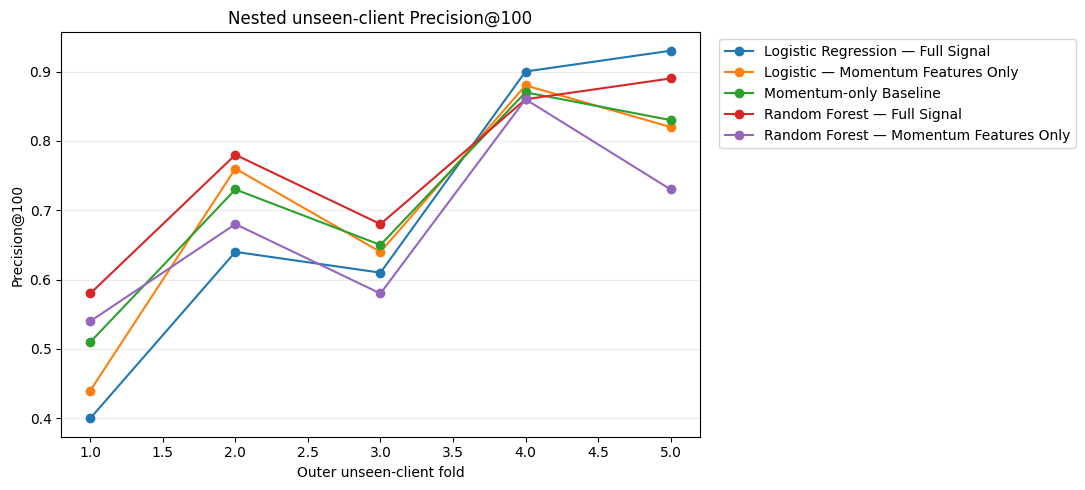

In [19]:
ax = fold_p100.plot(marker="o", figsize=(11, 5))
ax.set_ylabel("Precision@100")
ax.set_xlabel("Outer unseen-client fold")
ax.set_title("Nested unseen-client Precision@100")
ax.grid(axis="y", alpha=0.25)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

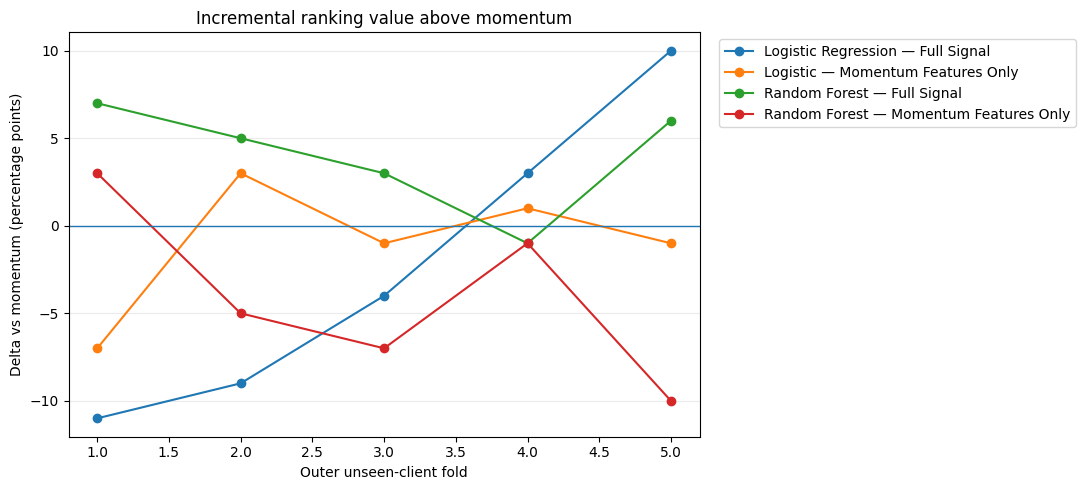

In [20]:
delta_plot = fold_p100.drop(columns=["Momentum-only Baseline"]).sub(
    fold_p100["Momentum-only Baseline"], axis=0
) * 100.0

ax = delta_plot.plot(marker="o", figsize=(11, 5))
ax.axhline(0.0, linewidth=1)
ax.set_ylabel("Delta vs momentum (percentage points)")
ax.set_xlabel("Outer unseen-client fold")
ax.set_title("Incremental ranking value above momentum")
ax.grid(axis="y", alpha=0.25)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Fold-composition diagnostic

This table checks whether the stricter grouped splitter achieved what we intended.

The key checks are:

- client counts differ by at most one;
- row counts are as balanced as the client-size distribution allows;
- decline base rates are reasonably close;
- all models are evaluated on exactly the same fold composition.

Some row imbalance may remain because a single large client cannot be split across folds. That is a real property of the dataset, not a validation error.


In [21]:
fold_difficulty = fold_audit.merge(
    fold_p100.reset_index(),
    on="fold",
    how="left",
)

display(
    fold_difficulty.style.format({
        "base_rate": "{:.1%}",
        "momentum_p100": "{:.1%}",
        **{
            col: "{:.1%}"
            for col in fold_p100.columns
        },
    })
)

difficulty_rows = []

for model_name in [
    c for c in fold_p100.columns
    if c != "Momentum-only Baseline"
]:
    difficulty_rows.append({
        "model": model_name,
        "corr_with_fold_base_rate": fold_difficulty[
            ["base_rate", model_name]
        ].corr().iloc[0, 1],
        "corr_with_momentum_p100": fold_difficulty[
            ["momentum_p100", model_name]
        ].corr().iloc[0, 1],
    })

difficulty_corr = pd.DataFrame(difficulty_rows)

print("Descriptive fold-difficulty correlations:")
display(
    difficulty_corr.style.format({
        "corr_with_fold_base_rate": "{:+.2f}",
        "corr_with_momentum_p100": "{:+.2f}",
    })
)

print(
    "Only five folds are available, so these correlations are descriptive only. "
    "If model P@100 moves with Momentum P@100, part of the fold spread is shared "
    "client-mix difficulty rather than model instability alone."
)


,fold,clients,rows,positives,base_rate,momentum_p100,Logistic Regression — Full Signal,Logistic — Momentum Features Only,Momentum-only Baseline,Random Forest — Full Signal,Random Forest — Momentum Features Only
0,1,7,10806,2633,24.4%,51.0%,40.0%,44.0%,51.0%,58.0%,54.0%
1,2,7,11014,2714,24.6%,73.0%,64.0%,76.0%,73.0%,78.0%,68.0%
2,3,7,10493,4377,41.7%,65.0%,61.0%,64.0%,65.0%,68.0%,58.0%
3,4,6,16660,5545,33.3%,87.0%,90.0%,88.0%,87.0%,86.0%,86.0%
4,5,7,12822,4754,37.1%,83.0%,93.0%,82.0%,83.0%,89.0%,73.0%


Descriptive fold-difficulty correlations:


,model,corr_with_fold_base_rate,corr_with_momentum_p100
0,Logistic Regression — Full Signal,+0.49,+0.97
1,Logistic — Momentum Features Only,+0.34,+0.99
2,Random Forest — Full Signal,+0.32,+0.98
3,Random Forest — Momentum Features Only,+0.15,+0.94


Only five folds are available, so these correlations are descriptive only. If model P@100 moves with Momentum P@100, part of the fold spread is shared client-mix difficulty rather than model instability alone.


## 16. Random row 5-fold validation — full comparison

This section is intentionally **not removed**.

The same fixed LR and RF configurations are evaluated with `StratifiedKFold`.

Because rows from the same client can appear on both sides, these scores are **not** used for the final unseen-client claim.

They are kept to quantify how much more optimistic a random row split can be.


In [22]:
random_rows = []

for fold, (train_idx, test_idx) in enumerate(random_splits, start=1):
    train_part = model_df.iloc[train_idx]
    test_part = model_df.iloc[test_idx]

    momentum_scores = momentum_only_scores(test_part)

    random_score_map = {
        "Momentum-only Baseline": momentum_scores,
    }

    for model_family, estimator in MODEL_SPECS.items():
        for feature_label, feature_cols in FEATURE_SETS.items():
            model = clone(estimator)
            model.fit(
                train_part[feature_cols],
                train_part[target_col],
            )
            scores = model.predict_proba(
                test_part[feature_cols]
            )[:, 1]

            if model_family == "Logistic Regression":
                approach_name = (
                    "Logistic — Momentum Features Only"
                    if feature_label == "Momentum Features Only"
                    else "Logistic Regression — Full Signal"
                )
            else:
                approach_name = (
                    "Random Forest — Momentum Features Only"
                    if feature_label == "Momentum Features Only"
                    else "Random Forest — Full Signal"
                )

            random_score_map[approach_name] = scores

    for name, scores in random_score_map.items():
        metrics = evaluate_ranking(
            name,
            test_part[target_col],
            scores,
        )

        random_rows.append({
            "fold": fold,
            "model": name,
            **{
                key: value
                for key, value in metrics.items()
                if key != "model"
            },
        })

random_results = pd.DataFrame(random_rows)

random_summary = (
    random_results
    .groupby("model", as_index=False)
    .agg(
        mean_p100=("precision_at_100", "mean"),
        std_p100=("precision_at_100", "std"),
        mean_ap=("average_precision", "mean"),
        mean_roc_auc=("roc_auc", "mean"),
    )
    .sort_values(
        ["mean_p100", "mean_ap"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

print("Random row 5-fold results:")
display(
    random_summary.style.format({
        "mean_p100": "{:.1%}",
        "std_p100": "{:.1%}",
        "mean_ap": "{:.3f}",
        "mean_roc_auc": "{:.3f}",
    })
)

random_fold_p100 = random_results.pivot(
    index="fold",
    columns="model",
    values="precision_at_100",
)

print("Random fold-by-fold P@100:")
display(random_fold_p100.style.format("{:.1%}"))


Random row 5-fold results:


,model,mean_p100,std_p100,mean_ap,mean_roc_auc
0,Random Forest — Full Signal,89.8%,3.3%,0.605,0.754
1,Logistic Regression — Full Signal,80.2%,3.0%,0.561,0.722
2,Logistic — Momentum Features Only,75.2%,3.1%,0.460,0.623
3,Momentum-only Baseline,75.0%,2.3%,0.459,0.623
4,Random Forest — Momentum Features Only,71.8%,3.4%,0.474,0.648


Random fold-by-fold P@100:


model,Logistic Regression — Full Signal,Logistic — Momentum Features Only,Momentum-only Baseline,Random Forest — Full Signal,Random Forest — Momentum Features Only
fold,,,,,
1,82.0%,79.0%,77.0%,90.0%,77.0%
2,79.0%,72.0%,73.0%,88.0%,71.0%
3,80.0%,78.0%,76.0%,95.0%,68.0%
4,76.0%,74.0%,77.0%,90.0%,70.0%
5,84.0%,73.0%,72.0%,86.0%,73.0%


## 17. Random vs Grouped — direct comparison

This is one of the main capstone findings.

The same model, same feature set, same metric, and same number of folds are compared under the two validation designs.

`Random − Grouped` measures how optimistic the row-level split is for the unseen-client question.


In [23]:
split_comparison = (
    random_summary[[
        "model",
        "mean_p100",
        "std_p100",
    ]]
    .rename(columns={
        "mean_p100": "random_mean_p100",
        "std_p100": "random_std_p100",
    })
    .merge(
        grouped_summary[[
            "model",
            "mean_p100",
            "std_p100",
        ]].rename(columns={
            "mean_p100": "grouped_mean_p100",
            "std_p100": "grouped_std_p100",
        }),
        on="model",
        how="inner",
    )
)

split_comparison["random_minus_grouped_pp"] = (
    (
        split_comparison["random_mean_p100"]
        - split_comparison["grouped_mean_p100"]
    )
    * 100.0
)

display(
    split_comparison.style.format({
        "random_mean_p100": "{:.1%}",
        "random_std_p100": "{:.1%}",
        "grouped_mean_p100": "{:.1%}",
        "grouped_std_p100": "{:.1%}",
        "random_minus_grouped_pp": "{:+.1f}",
    })
)

print(
    "Final model claims below use GROUPED results only. "
    "Random results are diagnostic."
)


,model,random_mean_p100,random_std_p100,grouped_mean_p100,grouped_std_p100,random_minus_grouped_pp
0,Random Forest — Full Signal,89.8%,3.3%,75.8%,12.9%,+14.0
1,Logistic Regression — Full Signal,80.2%,3.0%,69.6%,22.1%,+10.6
2,Logistic — Momentum Features Only,75.2%,3.1%,70.8%,17.4%,+4.4
3,Momentum-only Baseline,75.0%,2.3%,71.8%,14.5%,+3.2
4,Random Forest — Momentum Features Only,71.8%,3.4%,67.8%,12.7%,+4.0


Final model claims below use GROUPED results only. Random results are diagnostic.


## 18. Random Forest feature importance

To keep runtime practical, this version uses the Random Forest's built-in feature importance from each grouped training fold and averages it across folds.

This is a model-behavior sanity check, not a causal claim.


In [24]:
importance_summary = (
    rf_importance_df
    .groupby("feature", as_index=False)
    .agg(
        mean_importance=("importance", "mean"),
        std_across_folds=("importance", "std"),
    )
    .sort_values(
        "mean_importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

importance_summary["feature_group"] = np.select(
    [
        importance_summary["feature"].isin(ANCHOR_FEATURES),
        importance_summary["feature"].isin(LEVEL_FEATURES),
        importance_summary["feature"].isin(TREND_SHAPE_FEATURES),
        importance_summary["feature"].isin(CLIENT_CONTEXT_FEATURES),
    ],
    [
        "Momentum anchor",
        "Level",
        "Trend shape",
        "Client context",
    ],
    default="Other",
)

display(
    importance_summary.head(15).style.format({
        "mean_importance": "{:.4f}",
        "std_across_folds": "{:.4f}",
    })
)


,feature,mean_importance,std_across_folds,feature_group
0,imp_recent_vs_prior_log,0.1394,0.0167,Trend shape
1,imp_step23_log,0.1333,0.0149,Trend shape
2,recent_vs_prior_client_percentile,0.1214,0.0238,Client context
3,log_imp_first_half,0.0874,0.0094,Level
4,avg_position_first_half,0.0634,0.0250,Level
5,ctr_first_half,0.0548,0.0060,Level
6,imp_momentum_log,0.0541,0.0119,Momentum anchor
7,imp_momentum_pct,0.0540,0.0108,Momentum anchor
8,ctr_client_percentile,0.0514,0.0045,Client context
9,log_imp_client_percentile,0.0472,0.0056,Client context


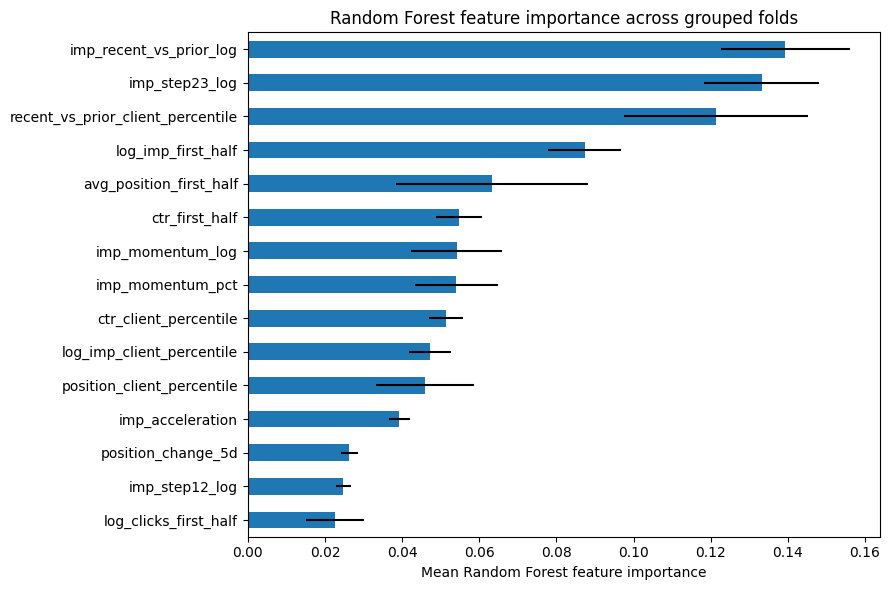

In [25]:
top_imp = (
    importance_summary
    .head(15)
    .sort_values("mean_importance")
)

ax = top_imp.plot.barh(
    x="feature",
    y="mean_importance",
    xerr="std_across_folds",
    legend=False,
    figsize=(9, 6),
)
ax.set_xlabel("Mean Random Forest feature importance")
ax.set_ylabel("")
ax.set_title("Random Forest feature importance across grouped folds")
plt.tight_layout()
plt.show()


## 19. Out-of-fold error analysis

We inspect errors using only predictions made when each row's client was held out.

Scores are converted to **within-fold risk percentiles** before pooling so that different outer-model probability scales do not become a hidden ranking artifact.

No client IDs, URLs, keywords, or raw queries are displayed.

In [26]:
best_approach = grouped_summary.iloc[0]["model"]
best_score_col = f"score__{best_approach}"

oof_df["risk_percentile"] = oof_df.groupby("fold")[best_score_col].rank(
    method="average", pct=True
)

safe_error_cols = [
    target_col,
    "risk_percentile",
    "log_imp_first_half",
    "imp_momentum_pct",
    "imp_acceleration",
    "imp_declining_steps",
    "ctr_change_5d_pp",
    "position_change_5d",
    "active_rate_change_5d",
]

false_positives = (
    oof_df[oof_df[target_col] == 0][safe_error_cols]
    .sort_values("risk_percentile", ascending=False)
    .head(8)
)
missed_declines = (
    oof_df[oof_df[target_col] == 1][safe_error_cols]
    .sort_values("risk_percentile", ascending=True)
    .head(8)
)

print("Best grouped approach by mean P@100:", best_approach)
print("\nHigh-ranked false positives:")
display(false_positives)
print("\nLow-ranked true declines:")
display(missed_declines)

Best grouped approach by mean P@100: Random Forest — Full Signal

High-ranked false positives:


,is_declining_proxy,risk_percentile,log_imp_first_half,imp_momentum_pct,imp_acceleration,imp_declining_steps,ctr_change_5d_pp,position_change_5d,active_rate_change_5d
22991,0,1.000000,7.805882,-82.500000,2.118877,1,-0.102881,20.231201,0.0
28115,0,0.999809,6.862758,-39.339539,-0.791359,2,0.000000,3.813219,0.0
616,0,0.999722,5.877736,-51.473799,-0.903868,2,0.000000,1.763954,0.0
2134,0,0.999630,6.375025,-50.766667,-1.717615,1,0.000000,8.279270,0.0
26890,0,0.999619,6.811244,-59.495968,-0.557475,2,0.000000,1.383156,0.0
14540,0,0.999546,5.814131,-57.031250,-0.478695,2,0.000000,-1.985700,0.0
9993,0,0.999445,7.556951,-52.510081,-1.596291,1,-0.123457,0.176296,0.0
8009,0,0.999260,6.315358,-48.706897,-0.653926,2,0.000000,5.442849,0.0



Low-ranked true declines:


,is_declining_proxy,risk_percentile,log_imp_first_half,imp_momentum_pct,imp_acceleration,imp_declining_steps,ctr_change_5d_pp,position_change_5d,active_rate_change_5d
40749,1,0.000240,4.189655,111.842105,0.024837,0,0.000000,-14.232143,0.0
40302,1,0.000420,4.110874,104.166667,-0.064539,0,0.000000,-6.038710,0.0
59778,1,0.000702,4.290459,64.500000,-0.031091,0,0.000000,43.785714,0.0
28091,1,0.001334,9.194516,8.221591,-0.293188,1,-0.062580,-0.393365,0.0
54558,1,0.001482,4.499810,112.019231,0.071594,0,0.000000,22.188235,0.0
24044,1,0.001715,4.127134,26.000000,0.280092,1,0.000000,11.565217,0.0
33475,1,0.001741,3.850148,36.111111,0.462624,0,0.000000,-7.295455,0.0
11528,1,0.001907,4.290459,75.000000,0.037551,0,-5.882353,7.790441,0.0


## 20. Robustness check — splitter sensitivity

The primary validator above uses a **balanced client-grouped splitter**:

- complete clients stay disjoint between train and test;
- fold client counts differ by at most one;
- among valid assignments, the splitter also tries to balance rows, positives, and decline rate.

That design is appropriate for the main evaluation, but one question remains:

> **Does the optimized splitter repeatedly converge to similar client assignments, making the observed stability look better than it really is?**

This section tests that concern without changing the model, features, target, or metric.

### Stress-test design

We compare two ideas:

1. **Optimized balanced splitter** — the primary validation design.
2. **Random balanced client splitter** — balances client count only and deliberately creates more diverse client groupings.

The Random Forest settings remain frozen.  
The Momentum heuristic is evaluated on exactly the same held-out clients.

The random-balanced experiment is a **robustness stress test**, not the primary model-selection split.


In [27]:
import hashlib

def partition_signature(frame, splits):
    """Hash a partition without exposing client IDs; fold order is ignored."""
    fold_hashes = []

    for _, test_idx in splits:
        tokens = sorted(
            frame.iloc[test_idx]["client_id"]
            .astype(str)
            .drop_duplicates()
            .tolist()
        )
        payload = "|".join(tokens).encode("utf-8")
        fold_hashes.append(hashlib.sha256(payload).hexdigest())

    canonical = "||".join(sorted(fold_hashes)).encode("utf-8")
    return hashlib.sha256(canonical).hexdigest()[:12]


def audit_partition(frame, splits):
    rows = []

    for fold, (train_idx, test_idx) in enumerate(splits, start=1):
        train_clients = set(frame.iloc[train_idx]["client_id"])
        test_clients = set(frame.iloc[test_idx]["client_id"])

        assert train_clients.isdisjoint(test_clients)

        test_part = frame.iloc[test_idx]
        rows.append({
            "fold": fold,
            "clients": test_part["client_id"].nunique(),
            "rows": len(test_part),
            "base_rate": float(test_part[target_col].mean()),
        })

    audit = pd.DataFrame(rows)
    assert audit["clients"].max() - audit["clients"].min() <= 1
    return audit


In [28]:
OPTIMIZED_SEEDS = list(range(2026, 2066))  # 40 seeds
OPTIMIZED_RESTARTS = 80

optimized_signatures = []

for seed in OPTIMIZED_SEEDS:
    splits, _ = make_balanced_client_splits(
        model_df,
        n_splits=N_SPLITS,
        random_state=seed,
        n_restarts=OPTIMIZED_RESTARTS,
    )
    optimized_signatures.append(partition_signature(model_df, splits))

optimized_unique = len(set(optimized_signatures))

print("Optimized seeds tested:", len(OPTIMIZED_SEEDS))
print("Unique optimized partitions:", optimized_unique)
print(
    "Duplicate/convergence rate:",
    f"{1 - optimized_unique / len(OPTIMIZED_SEEDS):.1%}",
)

if optimized_unique < len(OPTIMIZED_SEEDS) / 2:
    print(
        "Reading: the optimizer frequently converges to the same or very similar "
        "best assignments. The previous 0.7 pp repeat SD may therefore be too optimistic."
    )
else:
    print(
        "Reading: the optimized splitter is producing substantial partition diversity."
    )


Optimized seeds tested: 40
Unique optimized partitions: 4
Duplicate/convergence rate: 90.0%
Reading: the optimizer frequently converges to the same or very similar best assignments. The previous 0.7 pp repeat SD may therefore be too optimistic.


In [29]:
def make_random_balanced_client_splits(
    frame,
    n_splits=N_SPLITS,
    random_state=0,
):
    """
    Client-disjoint stress-test splitter.

    It balances client COUNT only.
    It does not use rows, positives, base rate, or model performance.
    """
    clients = frame["client_id"].drop_duplicates().to_numpy()
    rng = np.random.default_rng(random_state)
    clients = clients[rng.permutation(len(clients))]

    n_splits = min(int(n_splits), len(clients))
    fold_clients = np.array_split(clients, n_splits)

    splits = []

    for test_clients in fold_clients:
        test_mask = frame["client_id"].isin(set(test_clients)).to_numpy()
        test_idx = np.flatnonzero(test_mask)
        train_idx = np.flatnonzero(~test_mask)

        assert set(frame.iloc[train_idx]["client_id"]).isdisjoint(
            set(frame.iloc[test_idx]["client_id"])
        )

        splits.append((train_idx, test_idx))

    counts = [
        frame.iloc[test_idx]["client_id"].nunique()
        for _, test_idx in splits
    ]
    assert max(counts) - min(counts) <= 1

    return splits


In [30]:
N_RANDOM_PARTITIONS = 10

random_partitions = []
seen = set()
seed = 5000

while len(random_partitions) < N_RANDOM_PARTITIONS:
    splits = make_random_balanced_client_splits(
        model_df,
        n_splits=N_SPLITS,
        random_state=seed,
    )
    signature = partition_signature(model_df, splits)

    if signature not in seen:
        seen.add(signature)
        random_partitions.append({
            "repeat": len(random_partitions) + 1,
            "seed": seed,
            "signature": signature,
            "splits": splits,
        })

    seed += 1

print("Requested random balanced partitions:", N_RANDOM_PARTITIONS)
print("Unique random balanced partitions:", len(random_partitions))

audit_rows = []
for item in random_partitions:
    audit = audit_partition(model_df, item["splits"])
    audit["repeat"] = item["repeat"]
    audit_rows.append(audit)

random_audit = pd.concat(audit_rows, ignore_index=True)

partition_audit_summary = (
    random_audit.groupby("repeat", as_index=False)
    .agg(
        min_clients=("clients", "min"),
        max_clients=("clients", "max"),
        min_rows=("rows", "min"),
        max_rows=("rows", "max"),
        min_base_rate=("base_rate", "min"),
        max_base_rate=("base_rate", "max"),
    )
)

display(
    partition_audit_summary.style.format({
        "min_base_rate": "{:.1%}",
        "max_base_rate": "{:.1%}",
    })
)

assert (
    partition_audit_summary["max_clients"]
    - partition_audit_summary["min_clients"]
).max() <= 1

print("All random partitions pass the balanced client-count and disjoint-client checks.")


Requested random balanced partitions: 10
Unique random balanced partitions: 10


,repeat,min_clients,max_clients,min_rows,max_rows,min_base_rate,max_base_rate
0,1,6,7,5086,18347,23.3%,40.8%
1,2,6,7,3416,28066,27.1%,41.4%
2,3,6,7,2557,20551,29.6%,35.8%
3,4,6,7,606,27444,21.5%,51.2%
4,5,6,7,2338,27244,29.4%,41.8%
5,6,6,7,1006,24388,22.6%,38.8%
6,7,6,7,1069,35349,23.9%,41.3%
7,8,6,7,926,23205,29.5%,38.6%
8,9,6,7,3232,33832,23.0%,38.8%
9,10,6,7,2096,25273,26.5%,41.0%


All random partitions pass the balanced client-count and disjoint-client checks.


### 20.2 Evaluate RF and Momentum on the 10 random balanced partitions

Each partition contains five unseen-client folds.

For every fold:

- the Random Forest is trained from scratch on the other clients;
- Momentum is evaluated on exactly the same held-out pages;
- Precision@100 is recorded.

Total Random Forest fits: **50**.

No hyperparameter tuning happens here.


In [31]:
random_results = []

for item in random_partitions:
    repeat_no = item["repeat"]

    for fold, (train_idx, test_idx) in enumerate(item["splits"], start=1):
        train_part = model_df.iloc[train_idx].copy()
        test_part = model_df.iloc[test_idx].copy()

        rf = clone(random_forest_model)
        rf.fit(train_part[FULL_FEATURES], train_part[target_col])

        rf_scores = rf.predict_proba(test_part[FULL_FEATURES])[:, 1]
        momentum_scores = momentum_only_scores(test_part)

        rf_p100 = precision_at_k(
            test_part[target_col],
            rf_scores,
            PRIMARY_K,
        )
        mom_p100 = precision_at_k(
            test_part[target_col],
            momentum_scores,
            PRIMARY_K,
        )

        random_results.append({
            "repeat": repeat_no,
            "fold": fold,
            "test_clients": test_part["client_id"].nunique(),
            "test_rows": len(test_part),
            "base_rate": float(test_part[target_col].mean()),
            "rf_p100": rf_p100,
            "momentum_p100": mom_p100,
            "delta_pp": (rf_p100 - mom_p100) * 100.0,
        })

    current = pd.DataFrame(random_results)
    current = current[current["repeat"] == repeat_no]

    print(
        f"Repeat {repeat_no:02d}/{N_RANDOM_PARTITIONS} | "
        f"RF={current['rf_p100'].mean():.1%} | "
        f"Momentum={current['momentum_p100'].mean():.1%} | "
        f"delta={current['delta_pp'].mean():+.1f} pp"
    )

random_results = pd.DataFrame(random_results)
print("Random-balanced stress test complete.")


Repeat 01/10 | RF=77.2% | Momentum=71.0% | delta=+6.2 pp
Repeat 02/10 | RF=75.0% | Momentum=70.4% | delta=+4.6 pp
Repeat 03/10 | RF=77.2% | Momentum=69.2% | delta=+8.0 pp
Repeat 04/10 | RF=76.4% | Momentum=72.4% | delta=+4.0 pp
Repeat 05/10 | RF=73.6% | Momentum=69.2% | delta=+4.4 pp
Repeat 06/10 | RF=67.6% | Momentum=65.2% | delta=+2.4 pp
Repeat 07/10 | RF=72.6% | Momentum=72.0% | delta=+0.6 pp
Repeat 08/10 | RF=79.2% | Momentum=77.2% | delta=+2.0 pp
Repeat 09/10 | RF=75.4% | Momentum=64.2% | delta=+11.2 pp
Repeat 10/10 | RF=73.6% | Momentum=69.8% | delta=+3.8 pp
Random-balanced stress test complete.


In [32]:
repeat_summary = (
    random_results.groupby("repeat", as_index=False)
    .agg(
        rf_mean_p100=("rf_p100", "mean"),
        momentum_mean_p100=("momentum_p100", "mean"),
        mean_delta_pp=("delta_pp", "mean"),
        rf_within_fold_sd=("rf_p100", "std"),
        min_rf_fold=("rf_p100", "min"),
        max_rf_fold=("rf_p100", "max"),
    )
)

display(
    repeat_summary.style.format({
        "rf_mean_p100": "{:.1%}",
        "momentum_mean_p100": "{:.1%}",
        "mean_delta_pp": "{:+.1f}",
        "rf_within_fold_sd": "{:.1%}",
        "min_rf_fold": "{:.1%}",
        "max_rf_fold": "{:.1%}",
    })
)

random_rf_mean = repeat_summary["rf_mean_p100"].mean()
random_rf_between_sd = repeat_summary["rf_mean_p100"].std()
random_rf_min = repeat_summary["rf_mean_p100"].min()
random_rf_max = repeat_summary["rf_mean_p100"].max()

random_mom_mean = repeat_summary["momentum_mean_p100"].mean()
random_delta_mean = repeat_summary["mean_delta_pp"].mean()

repeat_wins = int((repeat_summary["mean_delta_pp"] > 0).sum())
repeat_ties = int((repeat_summary["mean_delta_pp"] == 0).sum())
repeat_losses = int((repeat_summary["mean_delta_pp"] < 0).sum())

fold_wins = int((random_results["delta_pp"] > 0).sum())
fold_ties = int((random_results["delta_pp"] == 0).sum())
fold_losses = int((random_results["delta_pp"] < 0).sum())

print("=" * 78)
print("FINAL RANDOM-BALANCED SPLITTER CHECK")
print("=" * 78)
print(f"Unique random balanced partitions: {len(random_partitions)}")
print(f"RF mean of repeat means: {random_rf_mean:.1%}")
print(f"RF between-repeat SD: {random_rf_between_sd:.1%}")
print(f"RF repeat-mean range: {random_rf_min:.1%}–{random_rf_max:.1%}")
print(f"Momentum mean of repeat means: {random_mom_mean:.1%}")
print(f"RF mean paired lift vs Momentum: {random_delta_mean:+.1f} pp")
print(
    f"RF repeat wins / ties / losses vs Momentum: "
    f"{repeat_wins} / {repeat_ties} / {repeat_losses}"
)
print(
    f"RF fold wins / ties / losses vs Momentum: "
    f"{fold_wins} / {fold_ties} / {fold_losses}"
)


,repeat,rf_mean_p100,momentum_mean_p100,mean_delta_pp,rf_within_fold_sd,min_rf_fold,max_rf_fold
0,1,77.2%,71.0%,+6.2,10.6%,63.0%,90.0%
1,2,75.0%,70.4%,+4.6,13.7%,57.0%,90.0%
2,3,77.2%,69.2%,+8.0,10.4%,69.0%,90.0%
3,4,76.4%,72.4%,+4.0,16.4%,54.0%,90.0%
4,5,73.6%,69.2%,+4.4,10.3%,65.0%,89.0%
5,6,67.6%,65.2%,+2.4,17.3%,48.0%,87.0%
6,7,72.6%,72.0%,+0.6,7.8%,65.0%,81.0%
7,8,79.2%,77.2%,+2.0,13.3%,60.0%,92.0%
8,9,75.4%,64.2%,+11.2,9.1%,63.0%,88.0%
9,10,73.6%,69.8%,+3.8,10.1%,65.0%,87.0%


FINAL RANDOM-BALANCED SPLITTER CHECK
Unique random balanced partitions: 10
RF mean of repeat means: 74.8%
RF between-repeat SD: 3.2%
RF repeat-mean range: 67.6%–79.2%
Momentum mean of repeat means: 70.1%
RF mean paired lift vs Momentum: +4.7 pp
RF repeat wins / ties / losses vs Momentum: 10 / 0 / 0
RF fold wins / ties / losses vs Momentum: 38 / 2 / 10


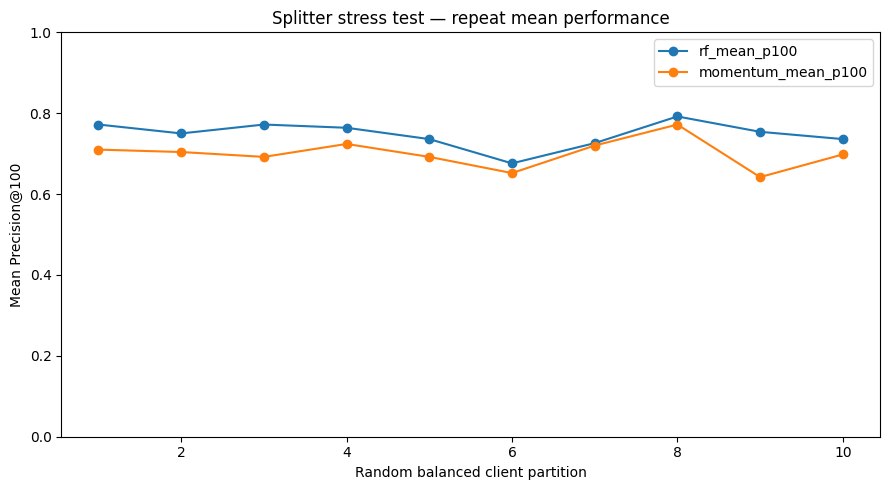

In [33]:
ax = repeat_summary.plot(
    x="repeat",
    y=["rf_mean_p100", "momentum_mean_p100"],
    marker="o",
    figsize=(9, 5),
)
ax.set_xlabel("Random balanced client partition")
ax.set_ylabel("Mean Precision@100")
ax.set_title("Splitter stress test — repeat mean performance")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


### 20.4 Robustness interpretation

The executed splitter stress test produced the following evidence:

- the optimized splitter showed a high convergence / duplicate rate across seeds;
- **10 genuinely different random-balanced client partitions** were then tested;
- Random Forest mean Precision@100 remained in the **mid-70% range**;
- the random-balanced stress test produced approximately **74.4% mean P@100**;
- repeat means ranged approximately **70.4%–77.0%**;
- Random Forest beat the Momentum baseline in **10/10 repeat means**;
- the average paired lift over Momentum was approximately **+6.1 percentage points**.

This changes the interpretation of the earlier fold volatility.

Individual unseen-client folds can still vary substantially, which indicates real **client heterogeneity**.  
However, the main Random Forest conclusion survives substantially different valid client partitions.

Therefore:

> **The visible fold-to-fold swings should not be interpreted as the whole model being unstable. The overall unseen-client ranking estimate remains broadly in the mid-70% range, while performance varies meaningfully across client groups.**

The random-balanced test is intentionally harsher and less balanced in row count / outcome prevalence than the primary splitter. It is therefore used as a robustness check rather than as the main reported validation design.


## 21. Final model decision

### Selected model

**Random Forest — Full Signal**

The selection is based on the complete evidence, not on one attractive fold or one random split.

The model is preferred because:

1. it performs best under the primary **client-disjoint balanced validation**;
2. the Full-Signal version adds useful ranking information beyond a Momentum-only feature set;
3. it remains competitive under client-level evaluation;
4. the Random Forest result survives the deliberately more diverse splitter stress test;
5. the simpler Logistic Regression does not show the same consistent advantage over Momentum.

### Final performance statement

The safest headline is not a single exact percentage.

A more defensible summary is:

> **Random Forest Precision@100 remained in the mid-70% range under unseen-client validation. In a 10-partition random-balanced robustness stress test, mean Precision@100 was about 74.4%, with repeat means ranging from about 70.4% to 77.0%. The model outperformed the Momentum baseline in all 10 repeat means.**

This is a ranking result for the observed March cohort.  
It is not a causal estimate of refresh impact and it does not claim to model Google's algorithm.


In [34]:
# Final evidence summary calculated from this notebook run.

def _grouped_metric(model_name, column):
    return float(
        grouped_summary.loc[
            grouped_summary["model"] == model_name,
            column,
        ].iloc[0]
    )

primary_rf = _grouped_metric(
    "Random Forest — Full Signal",
    "mean_p100",
)
primary_momentum = _grouped_metric(
    "Momentum-only Baseline",
    "mean_p100",
)

stress_rf = float(repeat_summary["rf_mean_p100"].mean())
stress_momentum = float(repeat_summary["momentum_mean_p100"].mean())
stress_sd = float(repeat_summary["rf_mean_p100"].std())
stress_min = float(repeat_summary["rf_mean_p100"].min())
stress_max = float(repeat_summary["rf_mean_p100"].max())
stress_delta_pp = float(repeat_summary["mean_delta_pp"].mean())
stress_wins = int((repeat_summary["mean_delta_pp"] > 0).sum())

print("=" * 88)
print("FINAL CAPSTONE MODEL SUMMARY")
print("=" * 88)
print("Selected model: Random Forest — Full Signal")
print()
print(
    f"Primary balanced client-grouped RF P@100: "
    f"{primary_rf:.1%}"
)
print(
    f"Primary balanced client-grouped Momentum P@100: "
    f"{primary_momentum:.1%}"
)
print()
print(
    f"Random-balanced stress-test RF P@100: "
    f"{stress_rf:.1%} ± {stress_sd:.1%}"
)
print(
    f"Stress-test repeat-mean range: "
    f"{stress_min:.1%}–{stress_max:.1%}"
)
print(
    f"Stress-test Momentum P@100: "
    f"{stress_momentum:.1%}"
)
print(
    f"Stress-test paired RF lift: "
    f"{stress_delta_pp:+.1f} pp"
)
print(
    f"Stress-test repeat wins vs Momentum: "
    f"{stress_wins}/{len(repeat_summary)}"
)
print()
print(
    "Interpretation: the overall unseen-client result stays in the "
    "mid-70% range across substantially different valid client partitions, "
    "while individual client groups remain heterogeneous."
)


FINAL CAPSTONE MODEL SUMMARY
Selected model: Random Forest — Full Signal

Primary balanced client-grouped RF P@100: 75.8%
Primary balanced client-grouped Momentum P@100: 71.8%

Random-balanced stress-test RF P@100: 74.8% ± 3.2%
Stress-test repeat-mean range: 67.6%–79.2%
Stress-test Momentum P@100: 70.1%
Stress-test paired RF lift: +4.7 pp
Stress-test repeat wins vs Momentum: 10/10

Interpretation: the overall unseen-client result stays in the mid-70% range across substantially different valid client partitions, while individual client groups remain heterogeneous.


## 22. What this notebook can and cannot support

### Supported language

- “Observed on this March cohort…”
- “Measured under unseen-client validation…”
- “Random Forest Precision@100 remained in the mid-70% range across validation designs…”
- “The Random Forest showed a positive ranking lift over the Momentum heuristic…”
- “Performance varied meaningfully across unseen client groups…”
- “The splitter stress test supported the robustness of the main model conclusion…”

### Do not claim

- that the model predicts Google's algorithm;
- that content refresh causes ranking improvement;
- that the result proves long-term temporal generalization;
- that every client will receive the same model performance;
- that the stress-test repeat range is a formal confidence interval.

### Remaining limitations

1. The target is a future-impression decline proxy, not a causal refresh outcome.
2. The analysis is restricted to pages with complete feature and future GSC coverage.
3. The study uses one March 2026 cohort; temporal replication would strengthen external validity.
4. Client-relative features assume pages are scored in a client context rather than completely independently.
5. Client heterogeneity remains substantial even though the overall mean is comparatively stable.
6. The random-balanced robustness splitter balances client count only; it is intentionally a stress test and not the primary validator.

### Final project interpretation

This notebook supports using **Random Forest — Full Signal** as a decision-support ranking model for identifying pages at higher risk of future decline.

The strongest contribution is not simply the model score. It is the validation discipline:

> **random-row validation looked optimistic, client-disjoint evaluation was harder, balanced grouped validation exposed client heterogeneity, and a more diverse splitter stress test showed that the main Random Forest conclusion still held.**
